# Compute statistics on scores

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ir_rpp.preprocessing import load_labels_and_runs, dataset_summary
from ir_rpp.scores import evaluate_preferences, aggregate_preferences, get_ordering
from ir_rpp.statistical_tests import (
    run_ttests,
    run_tukeys_hsd_test,
    run_kendal_tau,
    run_tau_ordering_comparison,
    plot_metric_correlations,
)

%load_ext autoreload
%autoreload 2

## Datasets (Table 1)

In [2]:
qrels, runs = load_labels_and_runs("libraryThing", binary_relevance=4)

Reading run files: 100%|██████████| 21/21 [00:17<00:00,  1.22it/s]


In [3]:
dataset_summary(qrels, runs)

requests                  7227
runs                        21
rel/request          13.146811
subtopics/request         todo
dtype: object

## Compute preferences and orderings

In [ ]:
ALL_METRICS = [
    "rpp",
    "invrpp",
    "dcgrpp",
    "ap",
    "ndcg",
    "rr",
]  # TODO: complete with others like ASL

In [ ]:
summary, preferences, raw_metrics = evaluate_preferences(
    qrels=qrels, runs=runs, measures=ALL_METRICS, query_eval_wanted=True
)

Iterating over qids:   0%|          | 0/7227 [00:00<?, ?it/s]

In [ ]:
pref_eval_output = summary + preferences + raw_metrics
system_orderings_by_query, system_orderings = aggregate_preferences(
    prefs=pref_eval_output, query_eval_wanted=True
)

## Correlation with existing metrics

### Correlation of query-level metric differences (Figure 5)

Note that it was originally done on `Robust` dataset. 

Note that for now metrics `ASL`, `OI` and `dcgOI` are missing. - TODO

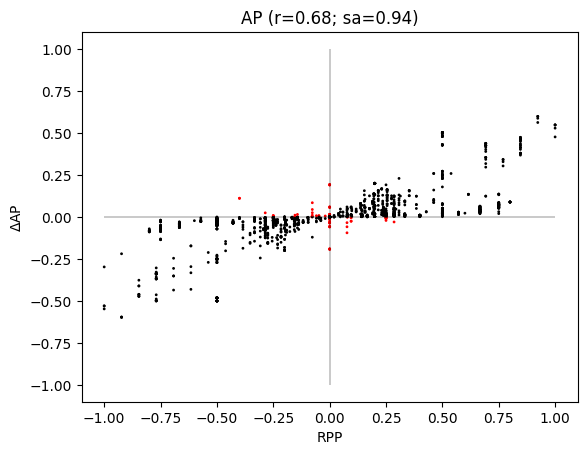

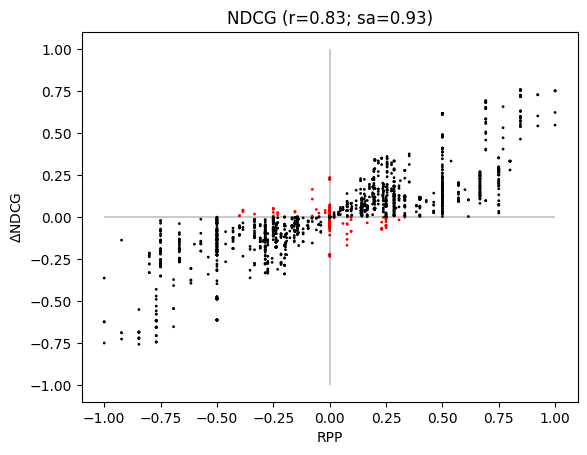

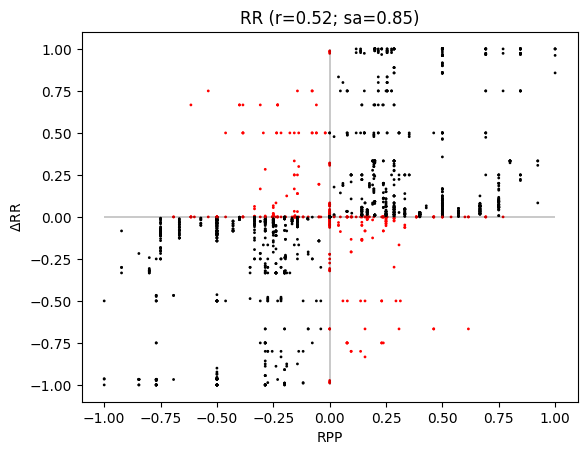

In [ ]:
plot_metric_correlations(preferences, ALL_METRICS, nb_queries=10)

### Compare orderings with Kendall's tau (Table 2)

Note that correlations are higher than in Table 2a since it's only for one dataset and e.g. `LibraryThing` is RecSys result, having few runs ans a lot of requests, so on average metrics may agree more.

Note that we need to obtain such data frames for all datasets and average them.

In [ ]:
run_tau_ordering_comparison(system_orderings, system_orderings_by_query, query_id=None)

,invrpp,rpp,dcgrpp,ap,ndcg
rr,0.885714,0.885714,0.885714,0.942857,0.942857
invrpp,NaN,1.0,1.0,0.92381,0.92381
rpp,NaN,NaN,1.0,0.92381,0.92381
dcgrpp,NaN,NaN,NaN,0.92381,0.92381
ap,NaN,NaN,NaN,NaN,1.0


## Robustness to incomplete data

### Missing requests (Figure 6)

In [9]:
# TODO

### Missing judgement labels (Figure 7)

In [10]:
# TODO

## Discriminative Power

### t-test with Bonferroni (Table 4a)

In [11]:
df_ttest, df_summary = run_ttests(preferences)
df_summary

metric,rpp,invrpp,dcgrpp,ap,ndcg,rr
significant,97.62,98.57,98.1,96.19,98.1,93.81


### Tukey's HSD test (Table 3a)

Algorithm implemented from *Carterette, Benjamin A. “Multiple Testing in Statistical Analysis of Systems-Based Information Retrieval Experiments.” ACM Trans. Inf. Syst. 30, no. 1 (2012): 4:1-4:34. https://doi.org/10.1145/2094072.2094076.*


In [ ]:
# NOTE: takes forever
# TODO: verify the algorithm implementation
df_ttest_hsd, df_summary_hsd = run_tukeys_hsd_test(preferences)
df_summary_hsd